# ML from DFT data

In [1]:
from sqlite3 import OptimizedUnicode
from unittest.mock import inplace

import matplotlib.pyplot as plt
import pandas as pd
from pygments.lexer import this

from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.DatasetTools.Commoms import *
from matplotlib.patches import Patch

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [3]:
figwidth, figheight = plt.rcParams['figure.figsize']
plt.rc('text', usetex=True)

# Parameters 

In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


# Targets

Text(0.5, 0, '$V_0$')

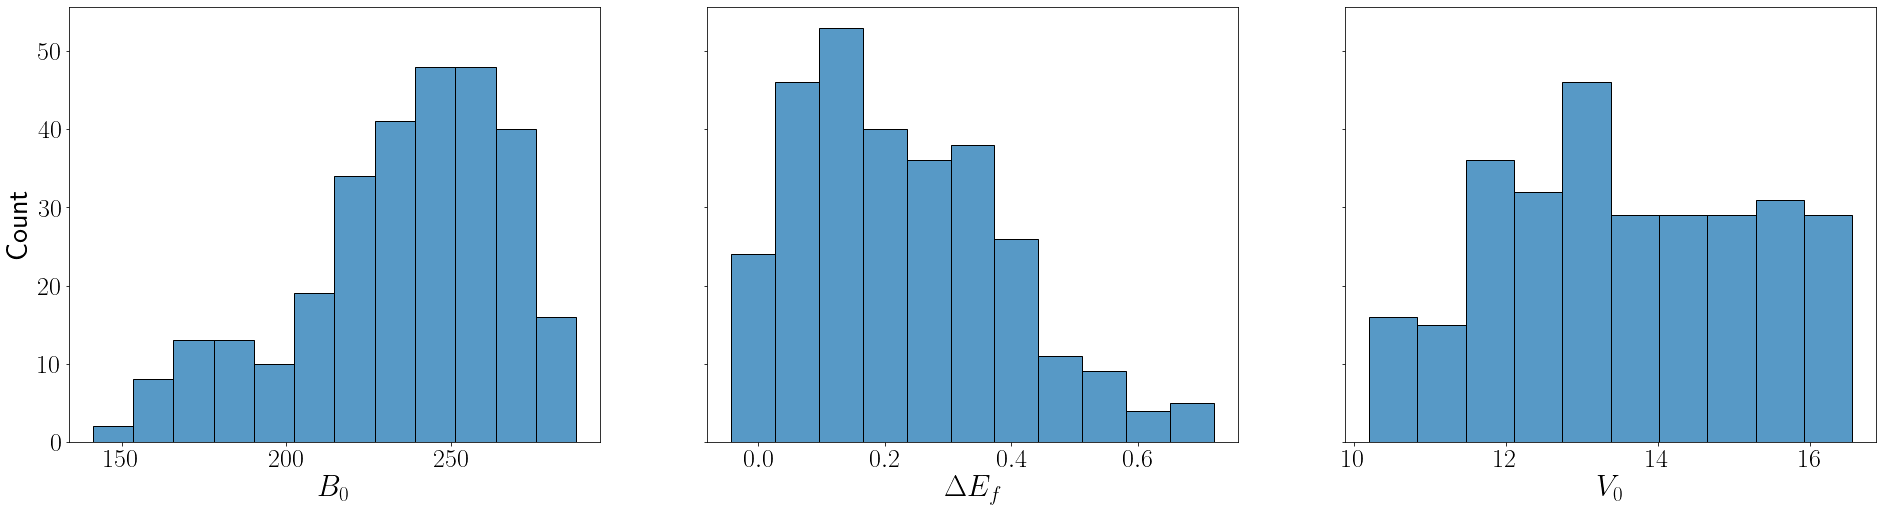

In [7]:
fig, ax = plt.subplots(1,3, figsize=(3*figwidth*(3/5), figheight), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
from Tools.DatasetTools.MLConveniences import *

In [9]:
resultslocation = DS.resultslocation

## Feature sets

In [10]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [11]:
Features['Canonical BOP']

,Structure,Mag,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,...,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,-6.925199,-6.050627,0.0,0.000000,0.000000,-0.874571,0.689619,0.571110,...,0.390118,1.081732,1.156282,0.0,0.000000,0.000000,0.901327,-82.472282,-84.309469,0.048237
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,-7.069580,-2.079584,0.0,-0.750946,-0.317244,-3.921805,0.690493,0.433446,...,0.137907,1.192249,1.343511,0.0,1.139857,0.956735,0.947607,-186.101697,-189.259613,0.829632
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,-6.601047,-2.125589,0.0,-3.588088,-0.477620,-0.409750,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.167253
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,-6.958838,-1.238417,0.0,-5.296760,-0.423661,0.000000,0.658999,0.243336,...,0.000000,1.224173,1.311938,0.0,1.187306,1.155462,0.000000,-106.073592,-106.249550,0.243741
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,-6.566157,-2.087629,0.0,-0.512510,-0.374860,-3.591159,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.331486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,2,1,-9.770953,-7.688316,0.0,0.000000,0.000000,-2.082637,1.635499,0.957173,...,0.618375,1.069390,1.032624,0.0,0.000000,0.000000,1.135754,-32.035307,-32.436815,0.508417
Mo_sv1.bcc.NM,5,0,-3.130925,0.000000,0.0,-3.130925,0.000000,0.000000,0.491648,0.000000,...,0.000000,1.261308,0.000000,0.0,1.261308,0.000000,0.000000,-3.130925,-3.130925,0.034169
Mo_sv8.A15.NM,0,0,-5.978096,-3.583571,0.0,-2.394525,0.000000,0.000000,0.531115,0.136149,...,0.000000,1.195488,1.177466,0.0,1.201725,0.000000,0.000000,-25.446069,-25.453952,0.971743
Mo_sv1.fcc.NM,7,0,-2.941773,-2.941773,0.0,0.000000,0.000000,0.000000,0.471662,0.471662,...,0.000000,1.140028,1.140028,0.0,0.000000,0.000000,0.000000,-2.941774,-2.941774,0.153146


In [12]:
for featurename in Features.keys():
    print(featurename)

atomic
dataset
SOAP_canonicalW_small
SOAP_specific_small
Pyscal
ACE
NOZERO-ACE
NOZERO_NOONE-ACE
NOZERO_NOONE_NOTWO-ACE
NOTHREE-ACE
NOTHREE-NOTWO-ACE
NOTHREE-NOTWO_NOONE-ACE
Canonical ACE
Canonical BOP
0.7dProjections 0.5OS BOP
0.7spProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
dataset + 0.7spProjections 0.5OS BOP
atomic no CNAV
dataset no CNAV
SOAP_canonicalW_small no CNAV
SOAP_specific_small no CNAV
Pyscal no CNAV
ACE no CNAV
NOZERO-ACE no CNAV
NOZERO_NOONE-ACE no CNAV
NOZERO_NOONE_NOTWO-ACE no CNAV
NOTHREE-ACE no CNAV
NOTHREE-NOTWO-ACE no CNAV
NOTHREE-NOTWO_NOONE-ACE no CNAV
Canonical ACE no CNAV
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV
dataset + 0.7spProjections 0.5OS BOP no CNAV


## test - train splits

In [13]:
samplesplit = DS.get_samplesplit()

# Optimized models

In [14]:
from Tools.DatasetTools.MLConveniences import filter_features
import joblib
dataset='Fe-Mo'

In [15]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [16]:
modelnames=[model.replace(' ','') for model in models]

In [17]:
voting_regressor_files = {modelname: os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')
                         for modelname in modelnames}

In [18]:
voting_regressor_files

{'KernelRidge': 'Fe-Mo/results/voting_regressor_KernelRidge.pkl',
 'RandomForest': 'Fe-Mo/results/voting_regressor_RandomForest.pkl',
 'MLP': 'Fe-Mo/results/voting_regressor_MLP.pkl'}

In [19]:
optimal_regressors = {}
for model in modelnames:
    optimal_regressors.update(joblib.load(voting_regressor_files[model]))

In [20]:
for key in optimal_regressors.keys():
    print(key)

('Kernel Ridge', 'atomic')
('Kernel Ridge', 'dataset')
('Kernel Ridge', 'Canonical ACE')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'ACE no CNAV')
('Kernel Ridge', 'ACE')
('Kernel Ridge', '0.7dProjections 0.5OS BOP')
('Kernel Ridge', '0.7spProjections 0.5OS BOP')
('Kernel Ridge', 'atomic no CNAV')
('Kernel Ridge', 'dataset no CNAV')
('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV')
('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV')
('Kernel Ridge', 'SOAP_specific_small')
('Kernel Ridge', 'SOAP_specific_small no CNAV')
('Kernel Ridge', 'Canonical ACE no CNAV')
('Random Forest', 'atomic')
('Random Forest', 'dataset')
('Random Forest', 'Canonical ACE')
('Random Forest', 'Canonical BOP')
('Random Forest', '0.7dProjections 0.5OS BOP')
('Random Forest', '0.7spProjections 0.5OS BOP')
('Random Forest', 'ACE no CNAV')
('Random Forest', 'ACE')
('Random Forest', 'atomic no CNAV')
('Random Forest', 'dataset no CNAV')
('Random Forest', '0.7dProjections 0.5OS BOP no CNAV')
('Random F

In [21]:
ytrain = {}
ytest = {}
for (modelname, featurename), optimalregressor in optimal_regressors.items():
    if modelname == 'Kernel Ridge' and 'BOP' in featurename:
        break

In [22]:
optimalregressor.fit(Features[featurename].loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7f872d0ae430>,
                                                                  kw_args={'learning_curve':                            train1     test1  \
bn_2_CN16                0.142167  0.149180   
sigma_7_CN16             0.124379  0.142944   
moments_1_CN16           0.120886  0.136959   
moments_15_CN15          0.116664  0.145424   
normed_moments_2_0       0.114602  0.147926   
Ainf_0_CN16              0.106516  0.149324...
Ainf_0_CN16              0.115636  0.109897  
moments_14_CN14          0.113024  0.106535  
...                           ...       ...  
an_2_CN15                0.099109  0.088989  
moments_2_CN12           0.099635  0.088253  
an_3_CN15                0.100128  0.088262  
an_7_CN15                0.100648  0.088304  
U_bond_atom_list_1_CN13  0.101056  0.088232  

[171 rows x 5 columns],
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=0.01, coef0=5,
                                                          degree=2,
                                                          kernel='polynomial'))]))])

In [23]:
ytrain = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['train']]),
                  index=DS.samplesplit['train']) 

In [24]:
ytest = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['test']]),
                  index=DS.samplesplit['test']) 

# Optimized scores

In [25]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [26]:
scoresfiles

{'Kernel Ridge': 'Fe-Mo/results/Fe-Mo_Kernel Ridge_OptimalScores_EF_nmhcp.pkl',
 'Random Forest': 'Fe-Mo/results/Fe-Mo_Random Forest_OptimalScores_EF_nmhcp.pkl',
 'MLP': 'Fe-Mo/results/Fe-Mo_MLP_OptimalScores_EF_nmhcp.pkl'}

In [27]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}


In [28]:
len(OptimizedScores)

3

In [29]:
optimized_scores = pd.concat(OptimizedScores.values(), axis = 0)


<AxesSubplot:>

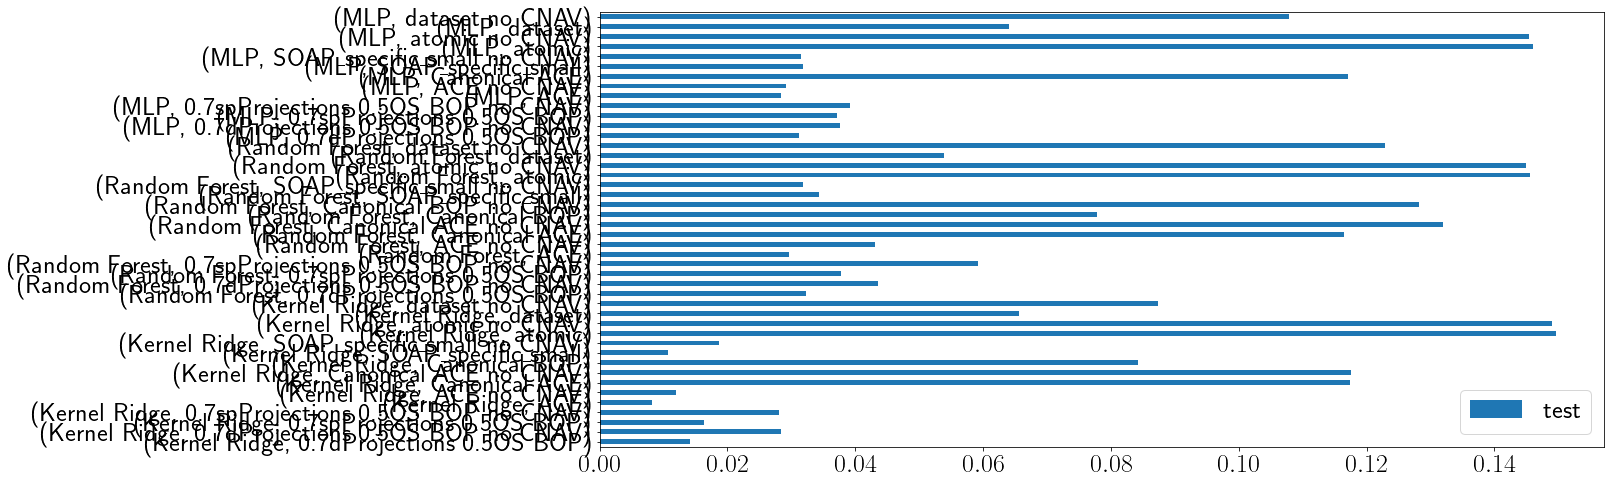

In [30]:
optimized_scores.plot.barh(y='test')

In [31]:
xs = {
    'ACE': 0,
    'SOAP' : 1,
    'BOP' : 2,
    'dataset' : 3,
    'Canonical BOP' : 4,
    'Canonical SOAP' : 5,
    'Canonical ACE' : 6,
    'atomic' : 7
}

In [32]:
for regname, scores in OptimizedScores.items():
    break

In [33]:
this_scores_nocnav = scores[scores.index.get_level_values(1).str.contains('no CNAV')].sort_values(by='test').reset_index()
this_scores_nocnav['label']=this_scores_nocnav.level_1.str.replace(' no CNAV','').str.replace( '.*dProjections .*BOP', 'BOP', regex=True).str.replace('.*spProjec.*BOP', 'sp BOP', regex=True).str.replace('.*SOAP.*', 'SOAP', regex=True)
#this_scores_nocnav.columns = pd.MultiIndex.from_tuples( [ ('no CNAV', colname) for colname in this_scores_nocnav.columns] )

In [34]:
this_scores_nocnav.index = this_scores_nocnav.level_1.str.replace(' no CNV', '')

In [35]:
this_scores_cnav = scores[~scores.index.get_level_values(1).str.contains('no CNAV')].sort_values(by='test').reset_index()
this_scores_cnav['label']  =this_scores_cnav.level_1.str.replace(' no CNAV','').str.replace('.*dProjections .*BOP', 'BOP', regex=True).str.replace('.*spProjec.*BOP', 'sp BOP', regex=True).str.replace('.*SOAP.*', 'SOAP', regex=True)

In [36]:
this_scores_cnav.index = this_scores_cnav.level_1.str.replace(' no CNV', '')

In [37]:
this_scores_nocnav.index = this_scores_nocnav.level_1.str.replace(' no CNV', '')

In [38]:
this_scores_cnav.test.get( wanted_indexes, np.nan)

NameError: name 'wanted_indexes' is not defined

In [ ]:
this_scores_cnav.test.get([ 'ACE', 'atomic', 'Canonical BOP', 'dataset' , 'BOP'])

In [ ]:
this_scores_cnav.index

In [ ]:
ax = sns.barplot(this_scores_cnav, y='label', x='test')

In [ ]:
ax = sns.barplot(this_scores_nocnav, y='label', x='test')

In [ ]:
this_scores_cnav.columns = pd.MultiIndex.from_tuples([('CNAV', colname) for colname in this_scores_cnav.columns])

In [ ]:
this_scores_cnav.index.get_level_values(1)


In [ ]:
this_scores_cnav.plot?

In [ ]:
this_scores_cnav.index.drop_level(1)

In [ ]:
this_scores_cnav.index.get_level_values(1)

In [ ]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

In [ ]:
OptimizedScoresDF.plot.bar()

In [ ]:
unstack = OptimizedScoresDF.unstack(level=0)

In [ ]:
unstack

In [39]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

NameError: name 'unstack' is not defined

In [40]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

NameError: name 'unstack' is not defined

In [41]:
test_scores

NameError: name 'test_scores' is not defined

In [42]:
no_cnav = {}
cnav = {}
regrouped= {}
for model in test_scores.columns:
    no_cnav[model] = test_scores.query('index.str.contains("no CNAV")')[[model]]
    cnav[model] = test_scores.query('~index.str.contains("no CNAV")')[[model]]
    no_cnav[model].index  = no_cnav[model].index.str.replace(' no CNAV','')
    regrouped[model] = pd.concat([ no_cnav[model], cnav[model] ], axis = 1)#.dropna()
    regrouped[model].columns = ['no CNAV', 'CNAV']
    regrouped[model].sort_values(by='CNAV', inplace=True)

NameError: name 'test_scores' is not defined

In [43]:
regrouped['Random Forest'] 

KeyError: 'Random Forest'

In [44]:
regrouped['Kernel Ridge']

KeyError: 'Kernel Ridge'

In [45]:
regrouped['MLP']

KeyError: 'MLP'

In [46]:
ModelName = 'MLP'
NameForFile = ModelName.replace(' ', '')
h = regrouped[ModelName].dropna().shape[0]
fig, ax =  plt.subplots() #(12, 1.2*(h+1))) #figsize=(5,4)
ax = (1000*regrouped[ModelName].dropna().sort_values(by='CNAV', ascending=False)).plot.barh(color = [ 'darkblue','mediumseagreen'], edgecolor='k', ax = ax, width=0.5)
ax.set_xscale('log', subs = [2,4,6,8,10])
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
newlabels = [l.replace('_specific','') for l in newlabels]
newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
#newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','polyhedra') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 Projections OS', 'Bond specific') for l in newlabels]
newlabels = [l.replace('polyhedra', 'atomic + OneHot') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_title(ModelName)
plt.tight_layout()
plt.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_structural_domain_{NameForFile}_{target_name}.pdf'))

KeyError: 'MLP'

In [47]:
models = pd.DataFrame.from_dict({modelname: regrouped_scores['CNAV'] for modelname, regrouped_scores in regrouped.items()})
models.sort_values(by=['Random Forest'], inplace=True, ascending=False)

KeyError: 'Random Forest'

In [ ]:
models = models[['Random Forest',  'MLP', 'Kernel Ridge']]

In [ ]:
models.index = models.index.str.replace('_specific','')

In [ ]:
models = models.query('~index.str.contains("^0.8|^0.6|canonicalFe")')

In [ ]:
models.dropna(inplace=True)

In [ ]:
models_nocnav = pd.DataFrame.from_dict({modelname: regrouped_scores['no CNAV'] for modelname, regrouped_scores in regrouped.items()})
models_nocnav.sort_values(by=['Kernel Ridge'], inplace=True, ascending=False)

In [ ]:
models_nocnav = models_nocnav[['Random Forest',  'MLP', 'Kernel Ridge']]

In [ ]:
models_nocnav.index = models_nocnav.index.str.replace('_specific','')

In [ ]:
models_nocnav = models_nocnav.query('~index.str.contains("^0.8|^0.6|canonicalFe")')

In [ ]:
models_nocnav.dropna(inplace=True)

In [43]:
data = models.melt()

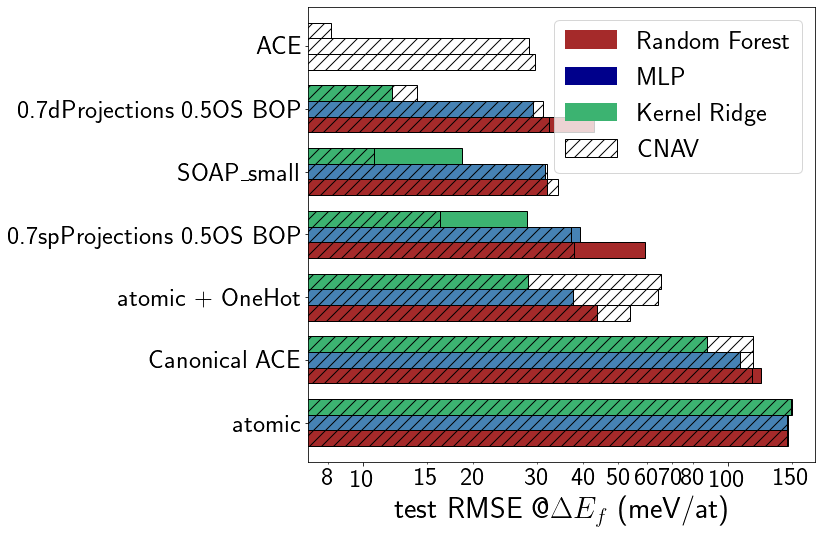

In [44]:
h = models.shape[0]
fig, ax = plt.subplots(figsize=(plt.rcParams['figure.figsize'][0]*(2/3),plt.rcParams['figure.figsize'][1]  ))#1.2*(h+1)))#figsize= (6,
thehatch = '//'
(1000*models_nocnav).plot.barh(
    color = [ 'brown', 'steelblue',  'mediumseagreen'],
    edgecolor='k',
#    alpha = 0.7,
    ax = ax, 
    width = 0.75,
    label='None',
    legend=False
)
(1000*models).plot.barh(
    facecolor = (1,1,1,0),
    edgecolor='k',
    ax = ax, 
    width = 0.75,
    hatch = thehatch,
    legend=False
)
ax.legend([]).remove()
ax.set_xscale('log', subs=[1.5, 2,3, 4,5, 6,7, 8,10])
xlabels = ax.get_yticklabels()
newlabels = [l.get_text().replace('+','+\n') for l in xlabels]
#newlabels = [l.replace('Pyscal','Steinhardt') for l in newlabels]
#newlabels = [l.replace('atomic','Matminer') for l in newlabels]
newlabels = [l.replace('dataset','atomic + OneHot') for l in newlabels]
newlabels = [l.replace('sOS','OS') for l in newlabels]
newlabels = [l.replace('0.7 Projections OS', 'Bond specific') for l in newlabels]
xls = ax.set_yticklabels(newlabels)
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
#plt.legend(ncol = 3, bbox_to_anchor = (0.1, 1, 1,0.2))
plt.legend(
    [Patch(facecolor='brown'),
     Patch(facecolor='darkblue'),
     Patch(facecolor='mediumseagreen'), 
     Patch(facecolor=(1,1,1,0.5), hatch=thehatch, ec='black')
    ],
    list(models.columns)+['CNAV'],
    ncol=1,
)
fig.tight_layout()
#fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_comparemodels_{target_name}.pdf'))
fig.savefig(os.path.join(DS.dataset,'graphs', f'Figure_OptimalRegresorComparison.pdf'))

# Accumulating knowledge

In [45]:
Y = DS.target

In [46]:
thisfeatures  = Features['Projections BOP'].filter(regex='normed_moments.*_0$')

In [47]:
thismodelname = 'Random Forest'

In [48]:
RMSEincremental = {}
for i, column in tqdm(enumerate(thisfeatures.columns), total = thisfeatures.shape[1]):
    X = pd.concat([Features['dataset']['Mag'],thisfeatures.iloc[:,:i+1]], axis=1)
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True)
    models[thismodelname].fit(xtrain, ytrain)
    Ypredict = models[thismodelname].predict(xtrain)
    Ypredicttest = models[thismodelname].predict(xtest)
    RMSEincremental[(thismodelname, column)] = {
        'train' : mean_squared_error(ytrain, Ypredict, squared = False),
        'test' : mean_squared_error(ytest, Ypredicttest, squared=False)
    }
    

  0%|          | 0/15 [00:00<?, ?it/s]

AttributeError: 'Series' object has no attribute 'fit'

In [ ]:
pd.DataFrame.from_dict(RMSEincremental, orient='index')

In [ ]:
thismodel = RandomForestRegressor()

In [ ]:
thismodel.fit(Features['dataset'], Y)

In [ ]:
Ypredict = thismodel.predict(Features['dataset'])

In [ ]:
mean_squared_error(Y, Ypredict, squared=False)

# Helper Functions 

In [ ]:
from Tools.DatasetTools.Tools import CaseNamer, Plotting

In [ ]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [ ]:
DS.dataset

## Load the BOP for the selected case

# Classification and weighting

In [ ]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [ ]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [ ]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [ ]:
from sklearn.feature_selection import  (RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [ ]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [ ]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

In [ ]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [ ]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [ ]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [ ]:
simple_model.fit(X_train,Y_train)

In [ ]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [ ]:
mses

In [ ]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [ ]:
simple_model_noscaler.fit(X_train, Y_train)

In [ ]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [ ]:
mses

In [ ]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

In [ ]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [ ]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

In [ ]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

In [ ]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [ ]:
ERRORS[ERRORS > 0.35]

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [ ]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[real_feature], Y_train)

In [ ]:
simple_model = RandomForestRegressor()

In [ ]:
np.array(real_feature)[Selector.get_support()]

In [ ]:
simple_model.fit(X_train[np.array(real_feature)[Selector.get_support()]], Y_train)

In [ ]:
Y_predict = simple_model.predict(X_train[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [ ]:
mses

### on a pipeline

In [ ]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [ ]:
RF_SelectKbest.fit(X_train, Y_train)

In [ ]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [ ]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

### with cross validation

In [ ]:
Params= {'feature_selection__k':np.arange(5,15), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [ ]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=2,n_jobs=2,)

In [ ]:
Validator.fit(X_train, Y_train)

In [ ]:
Validator.best_estimator_

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [ ]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [ ]:
y = Validator.cv_results_['mean_test_score']

In [ ]:
plt.plot(x,-y)

In [ ]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(10,20):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances, model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[allfeatures], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False),
    'features_selected': allfeatures, 'importances_selected' : model.feature_importances_
}

In [ ]:
mses

In [ ]:
with open('mses.pkl','wb') as f:
    pickle.dump(mses,f)

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, allfeatures,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [ ]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [ ]:
Selector.fit(X_train, Y_train)

In [ ]:
import joblib

In [ ]:
joblib.dump(Selector, 'SelectorRFECV')

In [ ]:
Selector.support_

In [ ]:
Selector.grid_scores_

In [ ]:
thisfeatures = X_train.columns[Selector.support_]

In [ ]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [ ]:
thisfeatures[order]

In [ ]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')